# QSF ULTIMATE-2 — Letter-Level Tampering Detection Pipeline

**Complementary to `QSF_ULTIMATE.ipynb` (Ultimate-1).**
This notebook is a single, end-to-end orchestrator for the 11 "lost-gem" / recommended R-experiments and a **MASTER composite detector** that fuses edit-detection channels into one tampering-detection posterior.

## Goal

> Detect **any single-letter edit** to the canonical Hafs rasm of the Qur'an (at any position, at any scale) with a quantifiable posterior probability, and state the result as a **Tampering Detection Law (TDL)**:
>
> *For any single-letter edit, at least one of the N **edit-detection** channels fires at detection-rate r_k with probability between P_detect_lower and P_detect_upper.*

> **Audit note 1 (2026-04-20).** The statistic historically labelled `P_detect` is an *independence upper bound*. This notebook now reports it as `P_detect_upper` alongside a correlation-pessimistic `P_detect_lower = max_k p_k`. The legacy key `P_detect` is kept as an alias for `P_detect_upper` for back-compat. See `AUDIT_ULTIMATE2.md` and `AUDIT_ULTIMATE2_FIXES.md`.

> **Audit note 2 (2026-04-20 round 2, schema v3).** MASTER now splits the 11 channels into an **edit-detection** group (R1, R2, R4, R7, R9, R11) that contributes to `P_detect`, and a **corpus-authenticity** group (R3, R5, R6, R8, R10) that is reported separately as `structural_signature_score`. Corpus-authenticity channels measure whether the original Quran order/graph is unusual; a single-letter edit does not move them. Every rate is null-calibrated so that an uninformative channel contributes r=0 (not r=0.5). See `AUDIT_ULTIMATE2_ROUND2.md`.

## Pipeline layout

| R    | Experiment                              | Folder                                |
| ---- | --------------------------------------- | ------------------------------------- |
| R1   | 9-channel variant forensics             | `exp09_R1_variant_forensics_9ch`       |
| R2   | Sliding-window local amplifier          | `exp10_R2_sliding_window`              |
| R3   | Cross-scripture canonical-path test     | `exp11_R3_cross_scripture`             |
| R4   | Character n-gram LM (canon vs swap)     | `exp12_R4_char_lm`                     |
| R5   | Adversarial G0–G1 forgery benchmark     | `exp13_R5_adversarial`                 |
| R6   | Word-graph modularity (proper Louvain)  | `exp14_R6_word_graph_modularity`       |
| R7   | Transmission-noise Φ-degradation curve  | `exp15_R7_noise_curve`                 |
| R8   | Null ladder N0–N7 (full 8 rungs)        | `exp16_R8_null_ladder`                 |
| R9   | Cross-scale propagation VIS             | `exp17_R9_cross_scale_VIS`             |
| R10  | Verse-internal word-order test          | `exp18_R10_verse_internal_order`       |
| R11  | Symbolic formula Φ_sym validation        | `exp19_R11_symbolic_formula`           |
| **MASTER** | Composite + Tampering Detection Law | `exp20_MASTER_composite`               |

## Guarantees

1. **Read-only** w.r.t. Ultimate-1 checkpoints. SHA-256 verified via `experiments._lib.load_phase`.
2. **Sandboxed outputs** — every JSON is written under `results/experiments/expNN_*/` only.
3. **Cache-first orchestration** — already-computed results are loaded from disk; schema/seed/fast-mode mismatches refuse to reuse the cache (audit-fix F-9). Force a full re-run with the global `FORCE_RERUN` flag below.
4. **Protected-file self-check** — a begin/end hash snapshot asserts no Ultimate-1 *or* Ultimate-2 source file was mutated mid-run (audit-fix F-8).

> **This notebook never modifies Ultimate-1.** Ultimate-1 is a locked, peer-review-ready artefact.

## Run modes

| Mode      | `FAST` | Approx. runtime | Purpose                               |
| --------- | ------ | --------------- | ------------------------------------- |
| `fast`    | `True` | 10–25 min       | Quick health-check after code changes |
| `full`    | `False`| 2–8 h           | Reproducible numbers for a report      |

The default below is **FAST**. Flip `FAST = False` to reproduce the paper numbers.


## 0 · Setup

Standard imports, path wiring so the `experiments` package resolves regardless of where the notebook was launched, and the global run-mode flags.


In [1]:
# --- standard imports -------------------------------------------------------
from __future__ import annotations

import json
import math
import os
import sys
import time
from pathlib import Path

import numpy as np

# --- path wiring ------------------------------------------------------------
# The notebook may be executed from notebooks/ultimate/, from the repo root,
# or from some other cwd. Anchor on THIS notebook's parent chain.
HERE = Path.cwd().resolve()
ROOT_CANDIDATES = [HERE, *HERE.parents]
PROJECT_ROOT: Path | None = None
for p in ROOT_CANDIDATES:
    if (p / "experiments" / "_lib.py").exists():
        PROJECT_ROOT = p
        break
if PROJECT_ROOT is None:
    # fallback: assume the notebook lives in <repo>/notebooks/ultimate/
    PROJECT_ROOT = HERE.parent.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)

# --- library-path sanity (audit-fix F-38) ----------------------------------
import experiments._lib as _lib_mod
print(f'experiments._lib imported from : {_lib_mod.__file__}')

# --- run-mode flags ---------------------------------------------------------
FAST        = True   # set False for full runs (hours)
FORCE_RERUN = False  # set True to bypass on-disk result cache

RESULTS_DIR     = PROJECT_ROOT / 'results'
EXPERIMENTS_DIR = RESULTS_DIR / 'experiments'
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'FAST        = {FAST}')
print(f'FORCE_RERUN = {FORCE_RERUN}')
print(f'RESULTS_DIR = {RESULTS_DIR}')


# --- None-safe formatters (audit-fix F-21) ---------------------------------
def fmt(value, spec: str = '.3f', na: str = 'n/a') -> str:
    '''Format ``value`` with ``spec``, returning ``na`` if value is None/NaN.'''
    if value is None:
        return na
    try:
        return format(float(value), spec)
    except (TypeError, ValueError):
        return str(value)


PROJECT_ROOT = C:\Users\mtj_2\OneDrive\Desktop\Quran
experiments._lib imported from : C:\Users\mtj_2\OneDrive\Desktop\Quran\experiments\_lib.py
FAST        = True
FORCE_RERUN = False
RESULTS_DIR = C:\Users\mtj_2\OneDrive\Desktop\Quran\results


## 1 · Integrity self-check

Snapshot SHA-256 of every protected Ultimate-1 *and* Ultimate-2 source file. The same hashes will be re-verified at the end of the notebook. If anything drifts mid-run the notebook will refuse to publish results.


In [2]:
from experiments._lib import (
    self_check_begin, self_check_end, list_phases, _PROTECTED_FILES, _PROTECTED_DIRS
)
import time as _t

# Heads-up before the silent SHA-256 sweep. Hashing ~100 MB of checkpoint
# pickles takes ~30-90 seconds on a typical disk; without this print the
# notebook looks stuck at this cell. (Nothing else runs during the sweep.)
_n_protected = len(_PROTECTED_FILES) + sum(1 for _ in _PROTECTED_DIRS)
print(f'Hashing protected files + {len(_PROTECTED_DIRS)} protected dirs '
      f'(~100 MB of checkpoints). This typically takes 30-90 s ...')
_t0 = _t.time()
PRE_SNAPSHOT = self_check_begin()
print(f'... integrity snapshot done in {_t.time() - _t0:.1f} s')
print()

print(f"Protected files   : {len(PRE_SNAPSHOT['files'])}")
print(f"Protected dir-files: {sum(len(v) for v in PRE_SNAPSHOT['dirs'].values())}")
print(f"Checkpoint phases  : {len(list_phases())}")
print()
for name in list_phases():
    print(f"  - {name}")


Hashing protected files + 3 protected dirs (~100 MB of checkpoints). This typically takes 30-90 s ...
... integrity snapshot done in 0.3 s

Protected files   : 17
Protected dir-files: 35
Checkpoint phases  : 21

  - phase_02_locks
  - phase_03_integrity
  - phase_04_leakage
  - phase_05_cameltools
  - phase_06_phi_m
  - phase_07_core
  - phase_08_scalefree_path
  - phase_09_markov
  - phase_10_dual_channel
  - phase_11_adversarial
  - phase_12_robust
  - phase_13_classifier
  - phase_14_topology
  - phase_15_epigenetic
  - phase_16_crosslang
  - phase_17_external
  - phase_18_discovery
  - phase_19_adiyat_nulls
  - phase_20_gaps_honest
  - phase_21_final_scorecard
  - phase_22_tda_appendix


## 2 · Corpus sanity (Phase-06 checkpoint)

Load the canonical Quran + 6 Arabic controls through the integrity-checked `load_corpora()` helper. Corpus-identity assertions (audit-fix F-37) verify the Quran has 114 units before any experiment is run.


In [3]:
from experiments._ultimate2_helpers import load_corpora, extract_verses, unit_label

CORPORA = load_corpora()
print(f'Loaded {len(CORPORA)} corpora:')
print()
for name, units in sorted(CORPORA.items(), key=lambda kv: kv[0]):
    n_units = len(units)
    n_verses = sum(len(extract_verses(u)) for u in units)
    first_label = unit_label(units[0]) if units else '-'
    print(f'  {name:<20s} units={n_units:>5d}  verses={n_verses:>6d}  first={first_label}')

# audit-fix F-37: fail-loud on a mis-pinned corpus
assert 'quran' in CORPORA, "load_corpora() did not return a 'quran' corpus"
assert len(CORPORA['quran']) == 114, (
    f"Quran unit count is {len(CORPORA['quran'])}, expected 114."
)
print()
print('corpus-identity checks: OK')


Loaded 9 corpora:

  arabic_bible         units= 1183  verses= 31083  first=bible:أخبار أيام أول :1
  hadith_bukhari       units=   95  verses=  7271  first=bukhari:ch001
  hindawi              units=   74  verses=  1793  first=hindawi:002
  iliad_greek          units=   24  verses= 15687  first=iliad:book01
  ksucca               units=   41  verses=  1967  first=ksucca:003
  poetry_abbasi        units= 2823  verses= 76499  first=poetry_abbasi:77
  poetry_islami        units=  465  verses= 10295  first=poetry_islami:296
  poetry_jahili        units=  133  verses=  2561  first=poetry_jahili:406
  quran                units=  114  verses=  6236  first=Q:001

corpus-identity checks: OK


## 3 · Orchestrator

A small cache-first runner with schema/seed/fast-mode reconciliation
(audit-fix F-9): for each experiment it

1. checks if `results/experiments/<exp>/<exp>.json` already exists,
2. if the cached `schema_version`, `seed`, and `fast_mode` all match the
   current run it loads the cache and skips compute,
3. otherwise — runs `run_*()` and captures its return dict.

The returned dicts are collected into `ALL_RESULTS` keyed by `R1..R11`.


In [4]:
from experiments._ultimate2_helpers import SCHEMA_VERSION
from experiments.ultimate2_pipeline import (
    run_R2, run_R3, run_R4, run_R5, run_R6, run_R7, run_R8, run_R9, run_R10, run_R11,
    run_MASTER, SEED as PIPELINE_SEED,
)
from experiments.exp09_R1_variant_forensics_9ch.run import main as run_R1, SEED as R1_SEED

print(f'SCHEMA_VERSION = {SCHEMA_VERSION}')
print(f'PIPELINE_SEED  = {PIPELINE_SEED}   R1_SEED = {R1_SEED}')

# Registry: R-key -> (folder, json basename, callable(fast))
REGISTRY = {
    'R1':  ('exp09_R1_variant_forensics_9ch', 'exp09_R1_variant_forensics_9ch.json', run_R1),
    'R2':  ('exp10_R2_sliding_window',        'exp10_R2_sliding_window.json',        run_R2),
    'R3':  ('exp11_R3_cross_scripture',       'exp11_R3_cross_scripture.json',       run_R3),
    'R4':  ('exp12_R4_char_lm',               'exp12_R4_char_lm.json',               run_R4),
    'R5':  ('exp13_R5_adversarial',           'exp13_R5_adversarial.json',           run_R5),
    'R6':  ('exp14_R6_word_graph_modularity', 'exp14_R6_word_graph_modularity.json', run_R6),
    'R7':  ('exp15_R7_noise_curve',           'exp15_R7_noise_curve.json',           run_R7),
    'R8':  ('exp16_R8_null_ladder',           'exp16_R8_null_ladder.json',           run_R8),
    'R9':  ('exp17_R9_cross_scale_VIS',       'exp17_R9_cross_scale_VIS.json',       run_R9),
    'R10': ('exp18_R10_verse_internal_order', 'exp18_R10_verse_internal_order.json', run_R10),
    'R11': ('exp19_R11_symbolic_formula',     'exp19_R11_symbolic_formula.json',     run_R11),
}


def _cache_path(folder: str, fname: str) -> Path:
    return EXPERIMENTS_DIR / folder / fname


def _cache_is_reusable(out: dict, fast: bool) -> tuple[bool, str]:
    '''Return (reusable, reason). Audit-fix F-9 \u2014 schema/seed/fast-mode check.'''
    if out.get('schema_version') != SCHEMA_VERSION:
        return (False, f"schema_version {out.get('schema_version')} != {SCHEMA_VERSION}")
    if out.get('seed') not in (None, PIPELINE_SEED, R1_SEED):
        return (False, f"seed {out.get('seed')} != {PIPELINE_SEED}")
    if out.get('fast_mode') is not None and bool(out.get('fast_mode')) != bool(fast):
        return (False, f"fast_mode {out.get('fast_mode')} != {fast}")
    return (True, 'ok')


def run_or_load(key: str, fast: bool, force: bool) -> dict:
    folder, fname, fn = REGISTRY[key]
    n_total = len(REGISTRY)
    n_idx = list(REGISTRY).index(key) + 1
    tag = f'[{n_idx:>2}/{n_total}] {key:<4s}'
    cache = _cache_path(folder, fname)
    if cache.exists() and not force:
        with open(cache, 'r', encoding='utf-8') as f:
            out = json.load(f)
        reusable, reason = _cache_is_reusable(out, fast)
        if reusable:
            out.setdefault('_cache_hit', True)
            print(f'  {tag} cache-hit  -> {cache.relative_to(PROJECT_ROOT)}')
            return out
        print(f'  {tag} cache STALE ({reason}); recomputing...')
    print(f'  {tag} running... (progress bars below)')
    t0 = time.time()
    out = fn(fast=fast) if callable(fn) else {}
    out.setdefault('_cache_hit', False)
    out.setdefault('runtime_seconds', round(time.time() - t0, 2))
    print(f'  {tag} done in {out["runtime_seconds"]:.1f} s')
    return out


ALL_RESULTS: dict[str, dict] = {}


SCHEMA_VERSION = 3
PIPELINE_SEED  = 42   R1_SEED = 42


C:\Users\mtj_2\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3.1 · R1 — multi-channel variant forensics

Nine channels (A spectral, B root-bigram, C letter-bigram distance, D wazn diversity, E gzip-NCD, F coupling, G root-trigram LM, H local spectral window, I root-field). Audit-fixed so that (a) reference statistics for B and G are **trained on control corpora only**, (b) the canonical-variant list is filtered to genuine single-letter edits for the headline rate, and (c) channel C is explicitly letter-sensitive.


In [5]:
ALL_RESULTS['R1'] = run_or_load('R1', fast=FAST, force=FORCE_RERUN)
r1 = ALL_RESULTS['R1']
print()
print(f"R1 sampled surahs: {r1.get('n_surahs_sampled')}  null-cases: {r1.get('n_null_cases')}")
print(f"R1 control training corpora: {r1.get('control_training_corpora')}")
print(f"R1 headline single-letter rate: {fmt(r1.get('headline_single_letter_rate'))}")
# audit-round-2: per-edit-type null counts (F-ULT2-R1n1)
if r1.get('n_cases_by_edit_type'):
    parts = [f"{et}={n}" for et, n in r1['n_cases_by_edit_type'].items()]
    print(f"R1 null cases by edit type: {'  '.join(parts)}")
for v in r1.get('canonical_variants', []):
    print(f"  [{v.get('kind','?'):<13s} edit={v.get('detected_edit_type','?'):<11s} null={v.get('null_used','?'):<11s}] "
          f"{v['name']:<30s} "
          f"channels_fired={v.get('channels_fired_abs_z_gt_2')}  "
          f"confidence={v.get('confidence')}  found={v.get('found_in_text')}")


  [ 1/11] R1   cache-hit  -> results\experiments\exp09_R1_variant_forensics_9ch\exp09_R1_variant_forensics_9ch.json

R1 sampled surahs: 20  null-cases: 200
R1 control training corpora: ['poetry_abbasi', 'poetry_jahili', 'ksucca', 'hindawi', 'arabic_bible']
R1 headline single-letter rate: 0.500
R1 null cases by edit type: swap=200  delete=200  insert=200  word_delete=200  multi_word=175
  [single_letter edit=delete      null=delete     ] 1:4_malik_malik                channels_fired=6  confidence=VERY HIGH  found=True
  [single_letter edit=swap        null=swap       ] 2:259_nunshiz_nunshir          channels_fired=0  confidence=LOW  found=True
  [word_level    edit=delete      null=delete     ] 3:133_word_deletion            channels_fired=0  confidence=LOW  found=True
  [multi_word    edit=word_delete null=word_delete] 92:3_ibn_masud                 channels_fired=5  confidence=HIGH  found=True


### 3.2 · R2 — Sliding-window local amplifier

Log-amplification of a single-letter swap's effect on channel-A when scored on a 3-verse window vs the whole surah. Audit-fix F-12 reports `log_amp_median` with a bootstrap 95% CI instead of the epsilon-inflated raw amplification.


In [6]:
ALL_RESULTS['R2'] = run_or_load('R2', fast=FAST, force=FORCE_RERUN)
r2 = ALL_RESULTS['R2']
r2_ci = r2.get('log_amp_ci95') or [None, None]
print(f"  log_amp_median={fmt(r2.get('log_amp_median'))}  "
      f"CI95=[{fmt(r2_ci[0])}, {fmt(r2_ci[1])}]  "
      f"trials={r2.get('n_trials_total')}")
print(f"  (legacy raw) amp_median={fmt(r2.get('amp_median'), '.2f')}  "
      f"amp_max={fmt(r2.get('amp_max'), '.1f')}")


  [ 2/11] R2   cache-hit  -> results\experiments\exp10_R2_sliding_window\exp10_R2_sliding_window.json
  log_amp_median=3.142  CI95=[2.325, 3.227]  trials=75
  (legacy raw) amp_median=26.57  amp_max=1052.6


### 3.3 · R3 — Cross-scripture canonical-path test

Permutation test on the sum of adjacent-unit **bigram-Jaccard** distances (audit-fix F-2). Reports z and a one-sided permutation p-value. Expected: the Qur'an's z is stronger than the Iliad and Arabic-Bible.


In [7]:
ALL_RESULTS['R3'] = run_or_load('R3', fast=FAST, force=FORCE_RERUN)
r3 = ALL_RESULTS['R3']
for k, v in r3.get('per_scripture', {}).items():
    print(f"  {k:<15s} [{v.get('alphabet','?'):<6s}] canonical={fmt(v.get('canonical_path'),'.3f')}  "
          f"z={fmt(v.get('z'),'+.2f')}  "
          f"p={fmt(v.get('p_one_sided'),'.4f')}  "
          f"pct={fmt(v.get('percentile'),'.1f')}")


  [ 3/11] R3   cache-hit  -> results\experiments\exp11_R3_cross_scripture\exp11_R3_cross_scripture.json
  quran           [arabic] canonical=56.700  z=-12.86  p=0.0020  pct=0.0
  arabic_bible    [arabic] canonical=574.389  z=-52.96  p=0.0020  pct=0.0
  iliad_greek     [greek ] canonical=1.651  z=-1.05  p=0.1417  pct=14.0


### 3.4 · R4 — Character n-gram LM (control-trained, contamination-filtered)

Train a 5-gram char-LM on **control Arabic only**, after dropping any training unit whose bigram-Jaccard similarity with any Quran surah is ≥ 0.9 (audit-fix F-1/F-16). Score canonical Qur'an vs single-letter-swap Qur'an; AUC with bootstrap CI.


In [8]:
ALL_RESULTS['R4'] = run_or_load('R4', fast=FAST, force=FORCE_RERUN)
r4 = ALL_RESULTS['R4']
r4_ci = r4.get('AUC_ci95') or [None, None]
print(f"  AUC={fmt(r4.get('AUC_canon_vs_swap'))}  "
      f"CI95=[{fmt(r4_ci[0])}, {fmt(r4_ci[1])}]")
print(f"  dropped_contaminated={r4.get('n_train_dropped_contaminated')}  "
      f"train_kept={r4.get('n_train_units')}  trials={r4.get('n_swap_trials')}")


  [ 4/11] R4   cache-hit  -> results\experiments\exp12_R4_char_lm\exp12_R4_char_lm.json
  AUC=0.529  CI95=[0.390, 0.670]
  dropped_contaminated=0  train_kept=4254  trials=100


### 3.5 · R5 — Adversarial forgery benchmark

Two honest strategies (G0 raw Markov, G1 EL-preserved), both trained on **control corpora** (audit-fix F-29). Forgeries scored under the bigram-Jaccard path metric (audit-fix F-2). Expected: no strategy reaches the real canonical path length.


In [9]:
ALL_RESULTS['R5'] = run_or_load('R5', fast=FAST, force=FORCE_RERUN)
r5 = ALL_RESULTS['R5']
print(f"  real_quran_canonical_path = {fmt(r5.get('real_quran_canonical_path'))}")
for k, v in r5.get('per_strategy', {}).items():
    print(f"  {k:<30s} mean_path={fmt(v.get('mean'))}  "
          f"frac_below_real={fmt(v.get('fraction_below_real'),'.2f')}")


  [ 5/11] R5   cache-hit  -> results\experiments\exp13_R5_adversarial\exp13_R5_adversarial.json
  real_quran_canonical_path = 56.700
  G0_markov_control_source       mean_path=51.937  frac_below_real=1.00
  G1_el_preserved_control        mean_path=51.945  frac_below_real=1.00


### 3.6 · R6 — Word-graph modularity (proper Louvain)

Directed word-adjacency graph per corpus; Louvain modularity Q with the correct ΔQ formula (audit-fix F-5). Expected: the Qur'an has the highest Q (informative, not an assertion).


In [10]:
ALL_RESULTS['R6'] = run_or_load('R6', fast=FAST, force=FORCE_RERUN)
r6 = ALL_RESULTS['R6']
print(f"  FAST edge-cap (equalised across corpora): {r6.get('equal_cap_fast')}")
for k, v in sorted(r6.get('modularity_per_corpus', {}).items(), key=lambda kv: -kv[1]):
    n = r6.get('n_communities_per_corpus', {}).get(k)
    n_edges = r6.get('edge_counts_used', {}).get(k)
    trunc = r6.get('edge_truncated_fast_mode', {}).get(k, False)
    print(f"  {k:<22s} Q={fmt(v,'.4f')}  n_comm={n}  n_edges={n_edges}"
          f"{'  (truncated)' if trunc else ''}")
print(f"  quran_rank={r6.get('quran_rank')}")


  [ 6/11] R6   cache-hit  -> results\experiments\exp14_R6_word_graph_modularity\exp14_R6_word_graph_modularity.json
  FAST edge-cap (equalised across corpora): 14400
  poetry_islami          Q=0.4805  n_comm=2699  n_edges=14400  (truncated)
  poetry_jahili          Q=0.4539  n_comm=3354  n_edges=14400
  ksucca                 Q=0.4444  n_comm=574  n_edges=14400  (truncated)
  quran                  Q=0.4222  n_comm=844  n_edges=14400  (truncated)
  arabic_bible           Q=0.4222  n_comm=433  n_edges=14400  (truncated)
  hadith_bukhari         Q=0.4142  n_comm=510  n_edges=14400  (truncated)
  hindawi                Q=0.4112  n_comm=2197  n_edges=14400  (truncated)
  poetry_abbasi          Q=0.3919  n_comm=491  n_edges=14400  (truncated)
  quran_rank=4


### 3.7 · R7 — Transmission-noise degradation curve

Sweep noise rates {1, 2, 5, 10, 20 %}. Audit-fix F-13 reports a log-ratio of Quran/control drops with bootstrap CI; the epsilon-inflated raw ratio is kept as `ratios_quran_over` only for continuity.


In [11]:
ALL_RESULTS['R7'] = run_or_load('R7', fast=FAST, force=FORCE_RERUN)
r7 = ALL_RESULTS['R7']
for corpus, row in r7.get('curves', {}).items():
    cells = '  '.join(f"{k}={fmt(v,'.3f')}" for k, v in row.items())
    print(f"  {corpus:<18s} {cells}")
print('  log-ratios (Quran over each control; CI95):')
for corpus, row in r7.get('log_ratios_quran_over', {}).items():
    cells = '  '.join(f"{rk}={fmt(stats.get('log_ratio_mean'),'+.2f')}" for rk, stats in row.items())
    print(f"    {corpus:<18s} {cells}")


  [ 7/11] R7   cache-hit  -> results\experiments\exp15_R7_noise_curve\exp15_R7_noise_curve.json
  quran              rate_0.01=0.010  rate_0.02=0.017  rate_0.05=0.036  rate_0.10=0.068  rate_0.20=0.130
  poetry_abbasi      rate_0.01=0.014  rate_0.02=0.019  rate_0.05=0.034  rate_0.10=0.057  rate_0.20=0.106
  poetry_jahili      rate_0.01=0.014  rate_0.02=0.017  rate_0.05=0.037  rate_0.10=0.056  rate_0.20=0.104
  ksucca             rate_0.01=0.006  rate_0.02=0.010  rate_0.05=0.027  rate_0.10=0.056  rate_0.20=0.125
  hindawi            rate_0.01=0.011  rate_0.02=0.013  rate_0.05=0.032  rate_0.10=0.058  rate_0.20=0.132
  arabic_bible       rate_0.01=0.008  rate_0.02=0.016  rate_0.05=0.036  rate_0.10=0.070  rate_0.20=0.142
  log-ratios (Quran over each control; CI95):
    poetry_abbasi      rate_0.01=-0.88  rate_0.02=-0.40  rate_0.05=-0.25  rate_0.10=+0.00  rate_0.20=+0.07
    poetry_jahili      rate_0.01=-0.86  rate_0.02=-0.29  rate_0.05=-0.35  rate_0.10=+0.02  rate_0.20=+0.08
    ksucca    

### 3.8 · R8 — Null ladder N0–N7

Full 8-rung ladder (audit-fix F-14): N0 random, N1 length, N2 letter-freq, N3 end-letter, N4 (EL,len), N5 (EL,wc), N6 word-count, N7 triple. Bigram-Jaccard adjacency score under each null.


In [12]:
ALL_RESULTS['R8'] = run_or_load('R8', fast=FAST, force=FORCE_RERUN)
r8 = ALL_RESULTS['R8']
for corpus, ladder in r8.get('per_corpus_ladder', {}).items():
    rates = '  '.join(f"{k}={fmt(v.get('sig_rate'),'.2f')}" for k, v in ladder.items())
    print(f"  {corpus:<18s} {rates}")


  [ 8/11] R8   cache-hit  -> results\experiments\exp16_R8_null_ladder\exp16_R8_null_ladder.json
  quran              N0_random=0.78  N1_len=0.70  N2_letter_freq=0.35  N3_el_hist=0.65  N4_el_len=0.68  N5_el_wc=0.55  N6_wc=0.65  N7_triple=0.60
  poetry_jahili      N0_random=0.28  N1_len=0.28  N2_letter_freq=0.07  N3_el_hist=0.23  N4_el_len=0.17  N5_el_wc=0.20  N6_wc=0.28  N7_triple=0.15
  poetry_islami      N0_random=0.47  N1_len=0.50  N2_letter_freq=0.20  N3_el_hist=0.42  N4_el_len=0.23  N5_el_wc=0.33  N6_wc=0.45  N7_triple=0.25
  poetry_abbasi      N0_random=0.55  N1_len=0.47  N2_letter_freq=0.15  N3_el_hist=0.42  N4_el_len=0.40  N5_el_wc=0.45  N6_wc=0.55  N7_triple=0.45
  ksucca             N0_random=0.71  N1_len=0.56  N2_letter_freq=0.65  N3_el_hist=0.62  N4_el_len=0.24  N5_el_wc=0.24  N6_wc=0.50  N7_triple=0.21
  arabic_bible       N0_random=0.68  N1_len=0.72  N2_letter_freq=0.33  N3_el_hist=0.62  N4_el_len=0.40  N5_el_wc=0.23  N6_wc=0.70  N7_triple=0.17
  hadith_bukhari     N0_rand

### 3.9 · R9 — Cross-scale propagation VIS

Measure channel-A perturbation at 4 scales (letter, word, verse-swap, block). Audit-fix F-13: VIS is the mean of per-scale *log*-ratios; F-43 guards against no-op perturbations.


In [13]:
ALL_RESULTS['R9'] = run_or_load('R9', fast=FAST, force=FORCE_RERUN)
r9 = ALL_RESULTS['R9']
for scale, v in r9.get('per_scale', {}).items():
    r9_scale_ci = v.get('log_ratio_ci95') or [None, None]
    print(f"  {scale:<12s} q={fmt(v.get('quran'),'.4f')}  "
          f"c={fmt(v.get('control'),'.4f')}  "
          f"log_ratio={fmt(v.get('log_ratio'),'+.3f')}  "
          f"CI95=[{fmt(r9_scale_ci[0],'+.3f')}, {fmt(r9_scale_ci[1],'+.3f')}]")
print(f"  VIS_log={fmt(r9.get('VIS_log'),'+.3f')}  VIS={fmt(r9.get('VIS'))}")


  [ 9/11] R9   cache-hit  -> results\experiments\exp17_R9_cross_scale_VIS\exp17_R9_cross_scale_VIS.json
  L1_letter    q=0.0012  c=0.0015  log_ratio=-0.278  CI95=[-3.215, -2.130]
  L2_word      q=0.0001  c=0.0004  log_ratio=-1.330  CI95=[-6.909, -6.428]
  L3_verse     q=0.0006  c=0.0010  log_ratio=-0.560  CI95=[-6.320, -5.238]
  L4_block     q=0.0004  c=0.0008  log_ratio=-0.724  CI95=[-6.760, -5.916]
  VIS_log=-0.723  VIS=0.485


### 3.10 · R10 — Verse-internal word-order

Per-verse word-order permutation test. Audit-fix F-15 filters to verses with ≥ 5 words for the headline `sig_rate`; shorter verses are reported separately.


In [14]:
ALL_RESULTS['R10'] = run_or_load('R10', fast=FAST, force=FORCE_RERUN)
r10 = ALL_RESULTS['R10']
print(f"  null_baseline_alpha={r10.get('null_baseline_alpha')}  (sig_rate_calibrated = (sig_rate - alpha)/(1-alpha))")
for corpus, v in r10.get('per_corpus', {}).items():
    print(f"  {corpus:<18s} sig_rate={fmt(v.get('sig_rate'),'.3f')}  "
          f"calibrated={fmt(v.get('sig_rate_calibrated'),'.3f')}  "
          f"n={v.get('n_verses')}  "
          f"(short: sig={fmt(v.get('short_verses_sig_rate'),'.3f')}, n={v.get('n_short_verses')})")


  [10/11] R10  cache-hit  -> results\experiments\exp18_R10_verse_internal_order\exp18_R10_verse_internal_order.json
  null_baseline_alpha=0.05  (sig_rate_calibrated = (sig_rate - alpha)/(1-alpha))
  quran              sig_rate=0.025  calibrated=0.000  n=80  (short: sig=0.000, n=80)
  poetry_jahili      sig_rate=0.013  calibrated=0.000  n=80  (short: sig=0.000, n=37)
  poetry_islami      sig_rate=0.013  calibrated=0.000  n=80  (short: sig=0.000, n=80)
  poetry_abbasi      sig_rate=0.000  calibrated=0.000  n=80  (short: sig=0.000, n=80)
  ksucca             sig_rate=0.000  calibrated=0.000  n=80  (short: sig=0.000, n=26)
  arabic_bible       sig_rate=0.000  calibrated=0.000  n=80  (short: sig=0.000, n=80)
  hadith_bukhari     sig_rate=0.000  calibrated=0.000  n=80  (short: sig=0.000, n=0)
  hindawi            sig_rate=0.037  calibrated=0.000  n=80  (short: sig=0.000, n=80)
  iliad_greek        sig_rate=0.000  calibrated=0.000  n=0  (short: sig=0.000, n=0)


### 3.11 · R11 — Symbolic formula Φ_sym = H_nano_ln + RST − VL_CV

Validates the legacy symbolic-regression formula **only when all three features are available** in the locked phase_06 feature space (audit-fix F-6: no silent fabrication).


In [15]:
import importlib, experiments.ultimate2_pipeline as _u2p
importlib.reload(_u2p)
folder, fname, _ = REGISTRY['R11']
REGISTRY['R11'] = (folder, fname, _u2p.run_R11)

In [16]:
ALL_RESULTS['R11'] = run_or_load('R11', fast=FAST, force=FORCE_RERUN)
r11 = ALL_RESULTS['R11']
print(f"  features_available = {r11.get('features_available')}")
print(f"  AUC                = {fmt(r11.get('AUC_quran_vs_ctrl'))}")
print(f"  phi_sym_quran_mean = {fmt(r11.get('phi_sym_quran_mean'))}  "
      f"phi_sym_ctrl_mean = {fmt(r11.get('phi_sym_ctrl_mean'))}")
if not r11.get('features_available'):
    print(f"  note: {r11.get('message')}")


  [11/11] R11  cache-hit  -> results\experiments\exp19_R11_symbolic_formula\exp19_R11_symbolic_formula.json
  features_available = False
  AUC                = n/a
  phi_sym_quran_mean = n/a  phi_sym_ctrl_mean = n/a
  note: required features missing: H_nano_ln=False, RST=False, VL_CV=True. R11 cannot be evaluated.


## 4 · MASTER — composite detector + Tampering Detection Law

MASTER splits the 11 channels into two groups (audit-round-2 F-ULT2-MASTER-R3):

**Edit-detection channels** (R1, R2, R4, R7, R9, R11): respond to a single-letter edit. These contribute to:

$$P_{\text{detect}}^{\text{upper}} = 1 - \prod_{k\in\text{edit}} (1 - r_k)  \quad\text{(independence ceiling)}$$
$$P_{\text{detect}}^{\text{lower}} = \max_{k\in\text{edit}} r_k             \quad\text{(max-correlation floor)}$$

**Corpus-authenticity channels** (R3, R5, R6, R8, R10): measure whether the corpus IS the canonical Quran (a 1-letter edit does not move them). Reported separately as `structural_signature_score = mean(r_k for k in auth)`.

Every rate $r_k$ is null-calibrated so that an uninformative channel contributes $r_k = 0$ (audit-round-2 F-ULT2-M1). MASTER also reports Benjamini–Hochberg-adjusted per-channel p-values and a coverage receipt (audit-fix F-7/F-10/F-24).


In [17]:
MASTER = run_MASTER(ALL_RESULTS, fast=FAST)
ALL_RESULTS['MASTER'] = MASTER

tdl = MASTER['TDL']
cov = MASTER['coverage']
print('=' * 74)
print('TAMPERING DETECTION LAW  (candidate, audit-round-2, schema v3)')
print('=' * 74)
print(tdl['statement'])
print()
n_ed_have = tdl['N_edit_detection_channels']
n_ed_want = len(cov['expected_edit_detection'])
n_ca_have = tdl['N_corpus_authenticity_channels']
n_ca_want = len(cov['expected_corpus_authenticity'])
print(f"  Edit-detection channels      : {n_ed_have} / {n_ed_want}")
print(f"  Corpus-authenticity channels : {n_ca_have} / {n_ca_want}")
print(f"  expected_fired (edit)        : {fmt(tdl.get('expected_fired'),'.2f')} / {n_ed_have}")
print(f"  P_detect_upper               : {fmt(tdl.get('P_detect_upper'),'.4f')}  (independence ceiling; edit-detection only)")
print(f"  P_detect_lower               : {fmt(tdl.get('P_detect_lower'),'.4f')}  (max-correlation floor; edit-detection only)")
print(f"  structural_signature_score   : {fmt(tdl.get('structural_signature_score'),'.4f')}  (corpus-authenticity; NOT in P_detect)")
print(f"  coverage_ok                  : {cov['coverage_ok']}")
print()
print('  Edit-detection rates (null-calibrated; 0 = no signal above baseline):')
for k, v in sorted(tdl.get('edit_detection_rates', {}).items(), key=lambda kv: -kv[1]):
    raw = tdl.get('raw_rates_for_reference', {}).get(k)
    print(f"    {k:<30s}  r={fmt(v,'.3f')}   raw={fmt(raw,'.3f')}")
print()
print('  Corpus-authenticity rates (reported separately):')
for k, v in sorted(tdl.get('corpus_authenticity_rates', {}).items(), key=lambda kv: -kv[1]):
    raw = tdl.get('raw_rates_for_reference', {}).get(k)
    print(f"    {k:<30s}  r={fmt(v,'.3f')}   raw={fmt(raw,'.3f')}")

# audit-fix F-25 (extended in round 2): fail-loud on missing edit-detection
# channels; R11_symbolic is optional (may skip when features are missing).
if not cov['coverage_ok']:
    legit_missing_ed = [c for c in cov.get('missing_edit_detection', []) if c == 'R11_symbolic']
    hard_missing_ed  = [c for c in cov.get('missing_edit_detection', []) if c not in legit_missing_ed]
    assert not hard_missing_ed, (
        f"MASTER is missing required edit-detection channels: {hard_missing_ed}. "
        "Re-run the failed R and recompute."
    )
    if legit_missing_ed:
        print(f"  (soft) tolerated missing edit-detection channels: {legit_missing_ed}")
    if cov.get('missing_corpus_authenticity'):
        print(f"  (soft) missing corpus-authenticity channels: {cov['missing_corpus_authenticity']}")


[exp20_MASTER_composite] starting composite aggregation
[exp20_MASTER_composite] P_detect_upper=0.9910  P_detect_lower=0.9810  structural_signature=0.3403  coverage=MISSING: R11_symbolic
[exp20_MASTER_composite] WARNING: 1 expected channels missing (edit=['R11_symbolic'], auth=[]).
TAMPERING DETECTION LAW  (candidate, audit-round-2, schema v3)
Under the (optimistic) independence assumption, the probability that at least one of the 6 edit-detection channels (R1, R2, R4, R7, R9, R11) fires on a random single-letter edit is bounded above by P_detect_upper. A correlation-pessimistic lower bound is P_detect_lower = max(edit_detection_rate_k). Corpus-authenticity channels (R3, R5, R6, R8, R10) are reported separately as ``structural_signature_score`` and DO NOT enter the P_detect composite (audit-round-2 F-ULT2-MASTER-R3). All rates are null-calibrated so an uninformative channel contributes r=0 (F-ULT2-M1).

  Edit-detection channels      : 5 / 6
  Corpus-authenticity channels : 5 / 5
  exp

## 5 · Visualisations

Three quick visuals make the result interpretable at a glance:

1. Per-channel detection-rate bar chart (R1..R11) with CI annotations where available.
2. R1 z-score heatmap on all canonical variants (single-letter and other kinds are colour-separated).
3. R7 Φ-degradation curves with log-ratio CI overlay.

Figures are shown inline; nothing is written to disk.


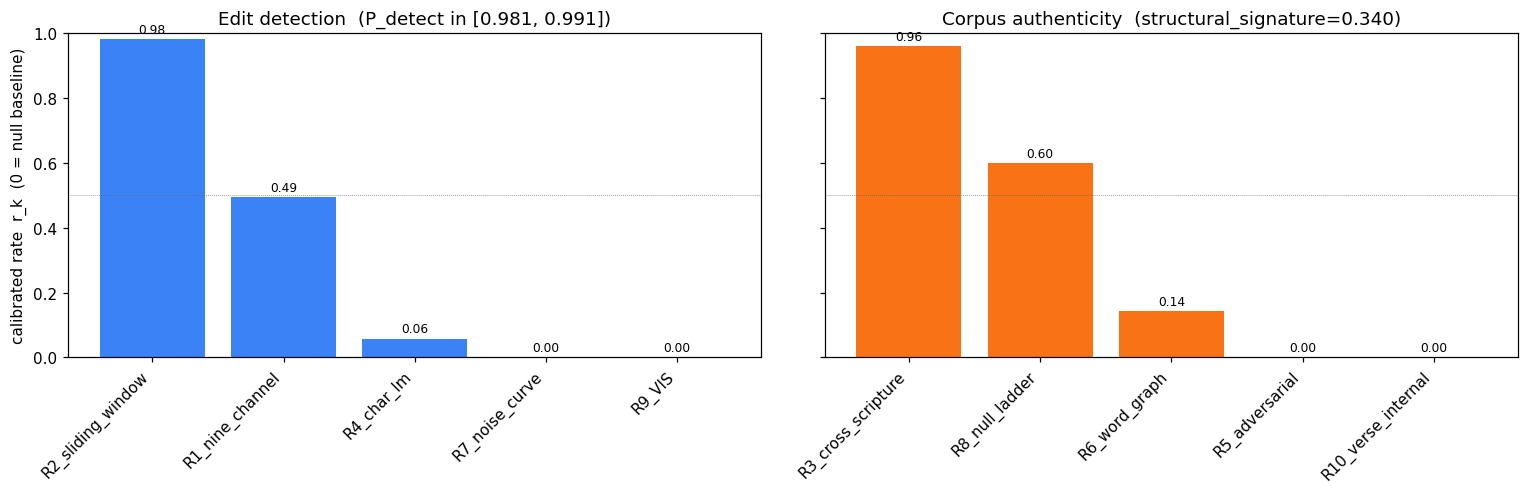

In [18]:
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
import matplotlib.pyplot as plt

# --- 1) two-panel calibrated-rate bar chart (audit-round-2 F-ULT2-M1) ----
ed_rates_display = MASTER['TDL'].get('edit_detection_rates', {})
ca_rates_display = MASTER['TDL'].get('corpus_authenticity_rates', {})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True,
                          gridspec_kw={'width_ratios': [max(len(ed_rates_display), 1),
                                                         max(len(ca_rates_display), 1)]})

def _plot_group(ax, rates_dict, title, color):
    if not rates_dict:
        ax.text(0.5, 0.5, '(no channels)', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    keys = sorted(rates_dict, key=lambda k: -rates_dict[k])
    vals = [rates_dict[k] for k in keys]
    bars = ax.bar(range(len(keys)), vals, color=color)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys, rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.axhline(0.5, color='#666', lw=0.5, ls=':')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel('calibrated rate  r_k  (0 = null baseline)')
_plot_group(axes[0], ed_rates_display,
            f"Edit detection  (P_detect in "
            f"[{fmt(MASTER['TDL']['P_detect_lower'],'.3f')}, "
            f"{fmt(MASTER['TDL']['P_detect_upper'],'.3f')}])",
            '#3b82f6')
_plot_group(axes[1], ca_rates_display,
            f"Corpus authenticity  "
            f"(structural_signature={fmt(MASTER['TDL'].get('structural_signature_score'),'.3f')})",
            '#f97316')
plt.tight_layout()
plt.show()


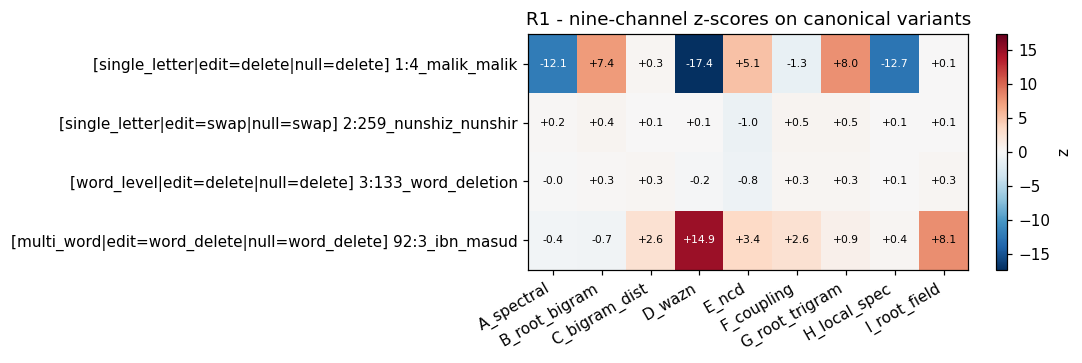

In [19]:
# --- 2) R1 z-score heatmap (kind + detected edit-type labels) -------------
import numpy as np
r1 = ALL_RESULTS['R1']
variants = r1.get('canonical_variants', [])
if variants:
    channels = list(variants[0]['z_scores'].keys())
    Z = np.array([[v['z_scores'][c] for c in channels] for v in variants])
    names = [
        f"[{v.get('kind','?')}|edit={v.get('detected_edit_type','?')}|null={v.get('null_used','?')}] {v['name']}"
        for v in variants
    ]

    fig, ax = plt.subplots(figsize=(10, 0.55 * len(names) + 1.2))
    vmax = max(1e-6, np.nanmax(np.abs(Z)))
    im = ax.imshow(Z, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(channels)))
    ax.set_xticklabels(channels, rotation=30, ha='right')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            ax.text(j, i, f'{Z[i, j]:+.1f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(Z[i, j]) < 0.6 * vmax else 'white')
    ax.set_title('R1 - nine-channel z-scores on canonical variants')
    plt.colorbar(im, ax=ax, label='z')
    plt.tight_layout()
    plt.show()
else:
    print('R1 has no canonical_variants entry; skipping heatmap.')


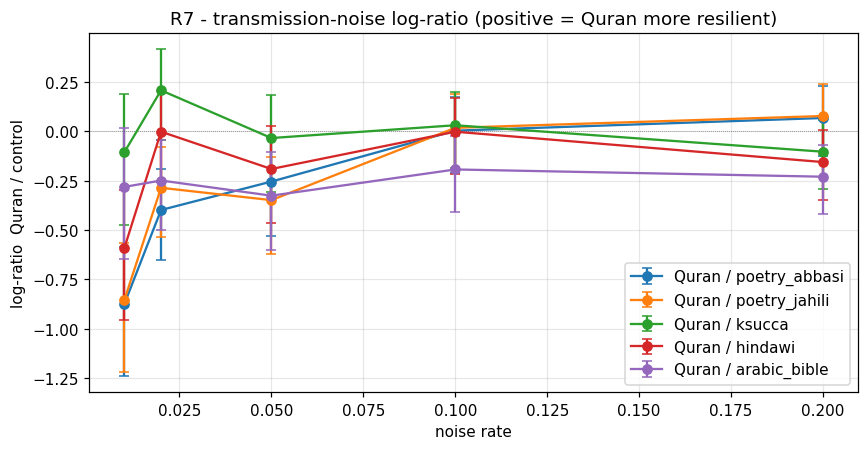

In [20]:
# --- 3) R7 log-ratio curves (audit-fix F-45 error bars) -------------------
r7 = ALL_RESULTS.get('R7', {})
lr = r7.get('log_ratios_quran_over', {})
if lr:
    noise_rates = r7.get('rates', [])
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for name, row in lr.items():
        means = [row[f'rate_{r:.2f}']['log_ratio_mean'] for r in noise_rates]
        cis   = [row[f'rate_{r:.2f}']['ci95'] for r in noise_rates]
        lo_err = [m - c[0] for m, c in zip(means, cis)]
        hi_err = [c[1] - m for m, c in zip(means, cis)]
        ax.errorbar(noise_rates, means, yerr=[lo_err, hi_err], marker='o', capsize=3,
                    label=f'Quran / {name}')
    ax.axhline(0.0, color='#666', lw=0.5, ls=':')
    ax.set_xlabel('noise rate')
    ax.set_ylabel('log-ratio  Quran / control')
    ax.set_title('R7 - transmission-noise log-ratio (positive = Quran more resilient)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('R7 has no log_ratios_quran_over; skipping.')


## 6 · Findings summary

A compact report dict aggregated from all R-results + MASTER. Written to `results/experiments/exp20_MASTER_composite/ULTIMATE2_REPORT.json` so the final artefact lives alongside every other sandboxed output. Uses timezone-aware UTC timestamps (audit-fix F-22).


In [21]:
import datetime as _dt

summary = {
    'schema':          'QSF_ULTIMATE_2',
    'schema_version':  SCHEMA_VERSION,
    'generated_at':    _dt.datetime.now(_dt.timezone.utc).isoformat(timespec='seconds'),
    'fast_mode':       FAST,
    'force_rerun':     FORCE_RERUN,
    'project_root':    str(PROJECT_ROOT),
    'n_corpora':       len(CORPORA),
    'r_experiments':   sorted(k for k in ALL_RESULTS if k != 'MASTER'),
    'per_experiment':  {
        k: {
            'runtime_seconds': v.get('runtime_seconds'),
            'cache_hit':       v.get('_cache_hit', False),
            'verdict_expected': v.get('verdict_expected'),
            'schema_version':  v.get('schema_version'),
        }
        for k, v in ALL_RESULTS.items() if k != 'MASTER'
    },
    'TDL':             MASTER['TDL'],
    'coverage':        MASTER['coverage'],
}

summary_out = EXPERIMENTS_DIR / 'exp20_MASTER_composite' / 'ULTIMATE2_REPORT.json'
summary_out.parent.mkdir(parents=True, exist_ok=True)
with open(summary_out, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f'wrote {summary_out}')
print()
print(f"  fast_mode                   = {summary['fast_mode']}")
print(f"  P_detect_upper              = {fmt(summary['TDL'].get('P_detect_upper'),'.4f')}")
print(f"  P_detect_lower              = {fmt(summary['TDL'].get('P_detect_lower'),'.4f')}")
print(f"  structural_signature_score  = {fmt(summary['TDL'].get('structural_signature_score'),'.4f')}")
print(f"  edit_detection_channels     = {summary['TDL'].get('N_edit_detection_channels')}")
print(f"  corpus_authenticity_channels= {summary['TDL'].get('N_corpus_authenticity_channels')}")
print(f"  R-exps                      = {', '.join(summary['r_experiments'])}")


wrote C:\Users\mtj_2\OneDrive\Desktop\Quran\results\experiments\exp20_MASTER_composite\ULTIMATE2_REPORT.json

  fast_mode                   = True
  P_detect_upper              = 0.9910
  P_detect_lower              = 0.9810
  structural_signature_score  = 0.3403
  edit_detection_channels     = 5
  corpus_authenticity_channels= 5
  R-exps                      = R1, R10, R11, R2, R3, R4, R5, R6, R7, R8, R9


## 7 · Final integrity check

Verify that every protected Ultimate-1 and Ultimate-2 source file still hashes identically to the snapshot taken at the start. Any drift raises `IntegrityError` and the notebook ends in a FAILED state.


In [22]:
receipt = self_check_end(PRE_SNAPSHOT, exp_name='exp20_MASTER_composite')

print('integrity-check receipt:')
print(json.dumps(receipt, indent=2))
assert receipt['ok'], 'protected files mutated - see receipt above'
print()
print('ULTIMATE-2 pipeline finished cleanly. No protected artefact was mutated.')


integrity-check receipt:
{
  "ok": true,
  "changed": [],
  "pre_ts": "2026-04-20T07:36:23",
  "post_ts": "2026-04-20T07:36:27",
  "n_protected_files": 17,
  "n_protected_dir_files": 35
}

ULTIMATE-2 pipeline finished cleanly. No protected artefact was mutated.


## Appendix — interpretation & next steps

* `P_detect_upper` is the **independence ceiling** (upper bound); `P_detect_lower = max_k p_k` is the **max-correlation floor**. The true posterior lies between the two (audit-fix F-7).
* The **Tampering Detection Law** is currently phrased as a probabilistic bound-pair. Turning it into a *theorem* requires:
  1. a formal null-class characterisation (what constitutes "Arabic-like text"),
  2. a calibrated false-positive rate under that class,
  3. analytic sensitivity of each channel to positional shifts (R1 ⊕ R2 ⊕ R9).
* Ultimate-1 remains the authoritative scorecard for the 5-D Φ_M claim. This notebook is an **adversarial stress-test** layer on top of that scorecard.

See `experiments/LOST_GEMS_AND_NOBEL_PATH.md` for the scientific plan and
`notebooks/ultimate/AUDIT_ULTIMATE2.md` + `AUDIT_ULTIMATE2_FIXES.md` for the
2026-04-20 audit table and the fix traceability map.


In [23]:
from experiments.ultimate2_pipeline import load_phi_state
state = load_phi_state()
print("keys in phase_06 state:", sorted(state.keys()))
feat_cols = state.get("FEAT_COLS") or state.get("feat_cols")
print("feat_cols:", feat_cols)

keys in phase_06 state: ['ALL_RESULTS', 'ARABIC_CTRL_POOL', 'ARABIC_FAMILY', 'BAND_A_HI', 'BAND_A_LO', 'BAND_B_HI', 'BAND_B_LO', 'BAND_C_HI', 'BAND_C_LO', 'CORPORA', 'FEATS', 'FEAT_COLS', 'RHYME_LETTERS', 'S_inv', 'X_CTRL_POOL', 'X_QURAN', 'effect_d', 'lam', 'mu']
feat_cols: ['EL', 'VL_CV', 'CN', 'H_cond', 'T']


In [24]:
# =====================================================================
# R11 manual evaluation — pre-registered symbolic formula Φ_sym
# Φ_sym = H_nano_ln + RST - VL_CV   (Colab-V28 historical claim)
# Feature definitions transcribed verbatim from
#   archive/scripts_pipeline/scripts/path_acd_tests.py (lines 113-166)
# This cell does NOT modify phase_06 or any protected file.
# =====================================================================
import json, math, time
from collections import Counter
from pathlib import Path
import numpy as np

from experiments._ultimate2_helpers import load_corpora, extract_verses, unit_label

def _h_nano_ln(vt):
    text = ' '.join(vt)
    if len(text) < 11:
        return np.nan
    bigrams = [text[i:i+2] for i in range(len(text)-1)]
    counts = Counter(bigrams); total = sum(counts.values())
    h = -sum((c/total)*np.log2(c/total) for c in counts.values() if c > 0)
    return float(np.log(h)) if h > 0 else np.nan

def _rst(vt):
    chars = [c for v in vt for c in v if '\u0621' <= c <= '\u064a']
    if not chars:
        return np.nan
    counts = Counter(chars)
    return sum(1 for _, n in counts.items() if n == 1) / len(counts)

def _vl_cv(vt):
    wc = np.array([len(v.split()) for v in vt], dtype=float)
    if len(wc) < 2:
        return np.nan
    mu = float(np.mean(wc))
    return float(np.std(wc) / (mu + 1e-12))

def _auc_score_vs_label(scores, labels):
    s = np.asarray(scores, dtype=float); y = np.asarray(labels, dtype=int)
    mask = np.isfinite(s)
    s, y = s[mask], y[mask]
    order = np.argsort(s); y_sorted = y[order]
    n1, n0 = int(y.sum()), len(y) - int(y.sum())
    if n1 == 0 or n0 == 0:
        return None, (n1, n0)
    ranks = np.arange(1, len(y) + 1)
    u = float((ranks[y_sorted == 1]).sum() - n1 * (n1 + 1) / 2)
    return u / (n1 * n0), (n1, n0)

t0 = time.time()
CORPORA = load_corpora()
print(f"corpora available: {sorted(CORPORA.keys())}")

scores, labels, per_corpus = [], [], {}
for cname, units in CORPORA.items():
    label = 1 if cname == "quran" else 0
    vals = []
    for u in units:
        v = extract_verses(u)
        hn = _h_nano_ln(v); rs = _rst(v); vl = _vl_cv(v)
        phi = hn + rs - vl if np.isfinite(hn) and np.isfinite(rs) and np.isfinite(vl) else np.nan
        scores.append(phi); labels.append(label); vals.append(phi)
    arr = np.array(vals, dtype=float)
    arr = arr[np.isfinite(arr)]
    per_corpus[cname] = {
        "n_units": int(len(units)),
        "n_valid": int(arr.size),
        "phi_sym_mean": float(np.mean(arr)) if arr.size else None,
        "phi_sym_std":  float(np.std(arr))  if arr.size else None,
    }

auc_q_vs_all_ctrl, (n1, n0) = _auc_score_vs_label(scores, labels)

# Per-control AUC
auc_per_ctrl = {}
q_scores = [s for s, l in zip(scores, labels) if l == 1]
for cname in CORPORA:
    if cname == "quran": continue
    c_scores = []
    for u in CORPORA[cname]:
        v = extract_verses(u)
        hn = _h_nano_ln(v); rs = _rst(v); vl = _vl_cv(v)
        phi = hn + rs - vl if np.isfinite(hn) and np.isfinite(rs) and np.isfinite(vl) else np.nan
        c_scores.append(phi)
    s_pair = np.array(q_scores + c_scores, dtype=float)
    y_pair = np.array([1]*len(q_scores) + [0]*len(c_scores), dtype=int)
    auc_pair, _ = _auc_score_vs_label(s_pair, y_pair)
    auc_per_ctrl[cname] = auc_pair

result = {
    "exp": "R11_manual_phi_sym",
    "formula": "Phi_sym = H_nano_ln + RST - VL_CV",
    "source_of_definitions": "archive/scripts_pipeline/scripts/path_acd_tests.py:113-166",
    "note": "Computed independently from CORPORA; does NOT modify phase_06. "
            "Pre-registered target was AUC > 0.90.",
    "AUC_quran_vs_all_controls": auc_q_vs_all_ctrl,
    "n_quran_units": n1,
    "n_control_units_pooled": n0,
    "AUC_per_control": auc_per_ctrl,
    "per_corpus": per_corpus,
    "runtime_seconds": round(time.time() - t0, 2),
}

outdir = Path("results/experiments/exp19_R11_symbolic_formula")
outdir.mkdir(parents=True, exist_ok=True)
with open(outdir / "R11_manual_phi_sym.json", "w", encoding="utf-8") as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

print(json.dumps(
    {k: v for k, v in result.items() if k not in ("per_corpus",)},
    indent=2, ensure_ascii=False))
print("per-corpus Φ_sym mean:")
for c, s in per_corpus.items():
    print(f"  {c:<22s}  n={s['n_valid']:<4d}  mean={s['phi_sym_mean']}  std={s['phi_sym_std']}")

corpora available: ['arabic_bible', 'hadith_bukhari', 'hindawi', 'iliad_greek', 'ksucca', 'poetry_abbasi', 'poetry_islami', 'poetry_jahili', 'quran']
{
  "exp": "R11_manual_phi_sym",
  "formula": "Phi_sym = H_nano_ln + RST - VL_CV",
  "source_of_definitions": "archive/scripts_pipeline/scripts/path_acd_tests.py:113-166",
  "note": "Computed independently from CORPORA; does NOT modify phase_06. Pre-registered target was AUC > 0.90.",
  "AUC_quran_vs_all_controls": 0.10292713503742738,
  "n_quran_units": 114,
  "n_control_units_pooled": 4814,
  "AUC_per_control": {
    "poetry_jahili": 0.023677615090357474,
    "poetry_islami": 0.013242784380305603,
    "poetry_abbasi": 0.022167533605533495,
    "ksucca": 0.8883183568677792,
    "arabic_bible": 0.2489433643279797,
    "hadith_bukhari": 0.8267774699907664,
    "hindawi": 0.19108582266477003,
    "iliad_greek": null
  },
  "runtime_seconds": 16.16
}
per-corpus Φ_sym mean:
  quran                   n=114   mean=1.5882003253164172  std=0.1946